<a href="https://colab.research.google.com/github/alealvaradoj131020/TextAnalytics_Proyecto/blob/main/ProyectoTextAnalytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análisis de sentimiento y modelado de tópicos**

**Proyecto Final Text Analytics - Master In Business Intelligence and Analytics**

Carlos Rivera - 251518

Daniel Cabrera - 252136

Alejandra Alvarado - 18263

## Caso de uso

El objetivo del proyecto es analizar reseñas de Amazon para identificar patrones lingüísticos asociados con opiniones positivas y negativas, y evaluar si es posible automatizar la clasificación del sentimiento de una reseña usando técnicas de NLP y aprendizaje automático.

Adicionalmente, se busca descubrir los temas principales presentes en las reseñas mediante modelado de tópicos, con el fin de generar conocimiento útil sobre la percepción del producto.

## **1. Carga de datos**

c:\Users\carlo\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\carlo\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


¡Éxito! Dataset cargado.
El dataset tiene 20000 filas y 2 columnas.
                                          reviewText  Positive
0  This is a one of the best apps acording to a b...         1
1  This is a pretty good version of the game for ...         1
2  this is a really cool game. there are a bunch ...         1
3  This is a silly game and can be frustrating, b...         1
4  This is a terrific game on any pad. Hrs of fun...         1


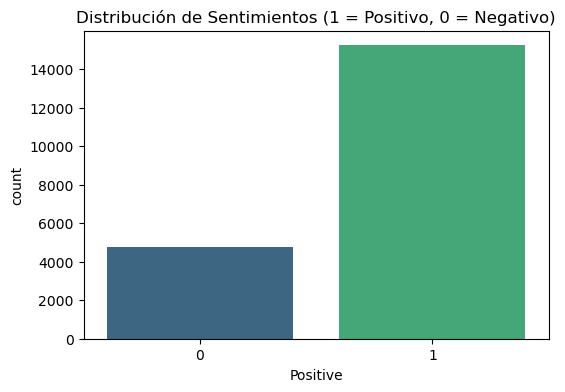

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/pycaret/pycaret/master/datasets/amazon.csv"

# Cargamos los datos
df = pd.read_csv(url)
print("¡Éxito! Dataset cargado.")
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")

# Mostramos las primeras 5 filas
print(df.head())

# Visualizamos si los datos están balanceados
plt.figure(figsize=(6,4))
sns.countplot(x='Positive', data=df, palette='viridis')
plt.title('Distribución de Sentimientos (1 = Positivo, 0 = Negativo)')
plt.show()

## **2. Pre-procesamiento de Datos**

In [3]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# Cargamos las herramientas necesarias de NLTK
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('punkt_tab')

# Definimos las palabras "vacías" (las que no queremos en el análisis)
stop_words = set(stopwords.words('english'))

# Inicializamos el Lematizador
lemmatizer = WordNetLemmatizer()

def limpiar_texto_avanzado(texto):
    # 1. Pasamos todo a minúsculas
    texto = str(texto).lower()

    # 2. Quitamos etiquetas HTML
    texto = re.sub(r'<.*?>', '', texto)

    # 3. Quitamos caracteres especiales y números
    texto = re.sub(r'<.*?>', '', texto)
    texto = re.sub(r'[^a-zA-Z\s]', '', texto)

    # 4. Tokenización
    palabras = nltk.word_tokenize(texto)

    # 5. Quitamos Stopwords y palabras muy cortas
    # También aplicamos Lematización a cada palabra
    palabras_limpias = [
        lemmatizer.lemmatize(p) for p in palabras
        if p not in stop_words and len(p) > 2
    ]

    # 6. Volvemos a unir las palabras en una sola cadena de texto
    return " ".join(palabras_limpias)

print("Iniciando limpieza de texto.")

# Creamos una nueva columna con el texto limpio
df['clean_text'] = df['reviewText'].apply(limpiar_texto_avanzado)

print("¡Limpieza completada!")

# Comparación de resultados
print("\n--- COMPARACIÓN DE RESULTADOS ---")
print(f"Original: {df['reviewText'].iloc[0][:100]}...")
print(f"Limpio:   {df['clean_text'].iloc[0][:100]}...")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\carlo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\carlo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\carlo\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\carlo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\carlo\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


Iniciando limpieza de texto.
¡Limpieza completada!

--- COMPARACIÓN DE RESULTADOS ---
Original: This is a one of the best apps acording to a bunch of people and I agree it has bombs eggs pigs TNT ...
Limpio:   one best apps acording bunch people agree bomb egg pig tnt king pig realustic stuff...


## **3. Visualización de Impacto**

c:\Users\carlo\anaconda3\lib\site-packages\seaborn\_core.py:1485: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
c:\Users\carlo\anaconda3\lib\site-packages\seaborn\_core.py:1485: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


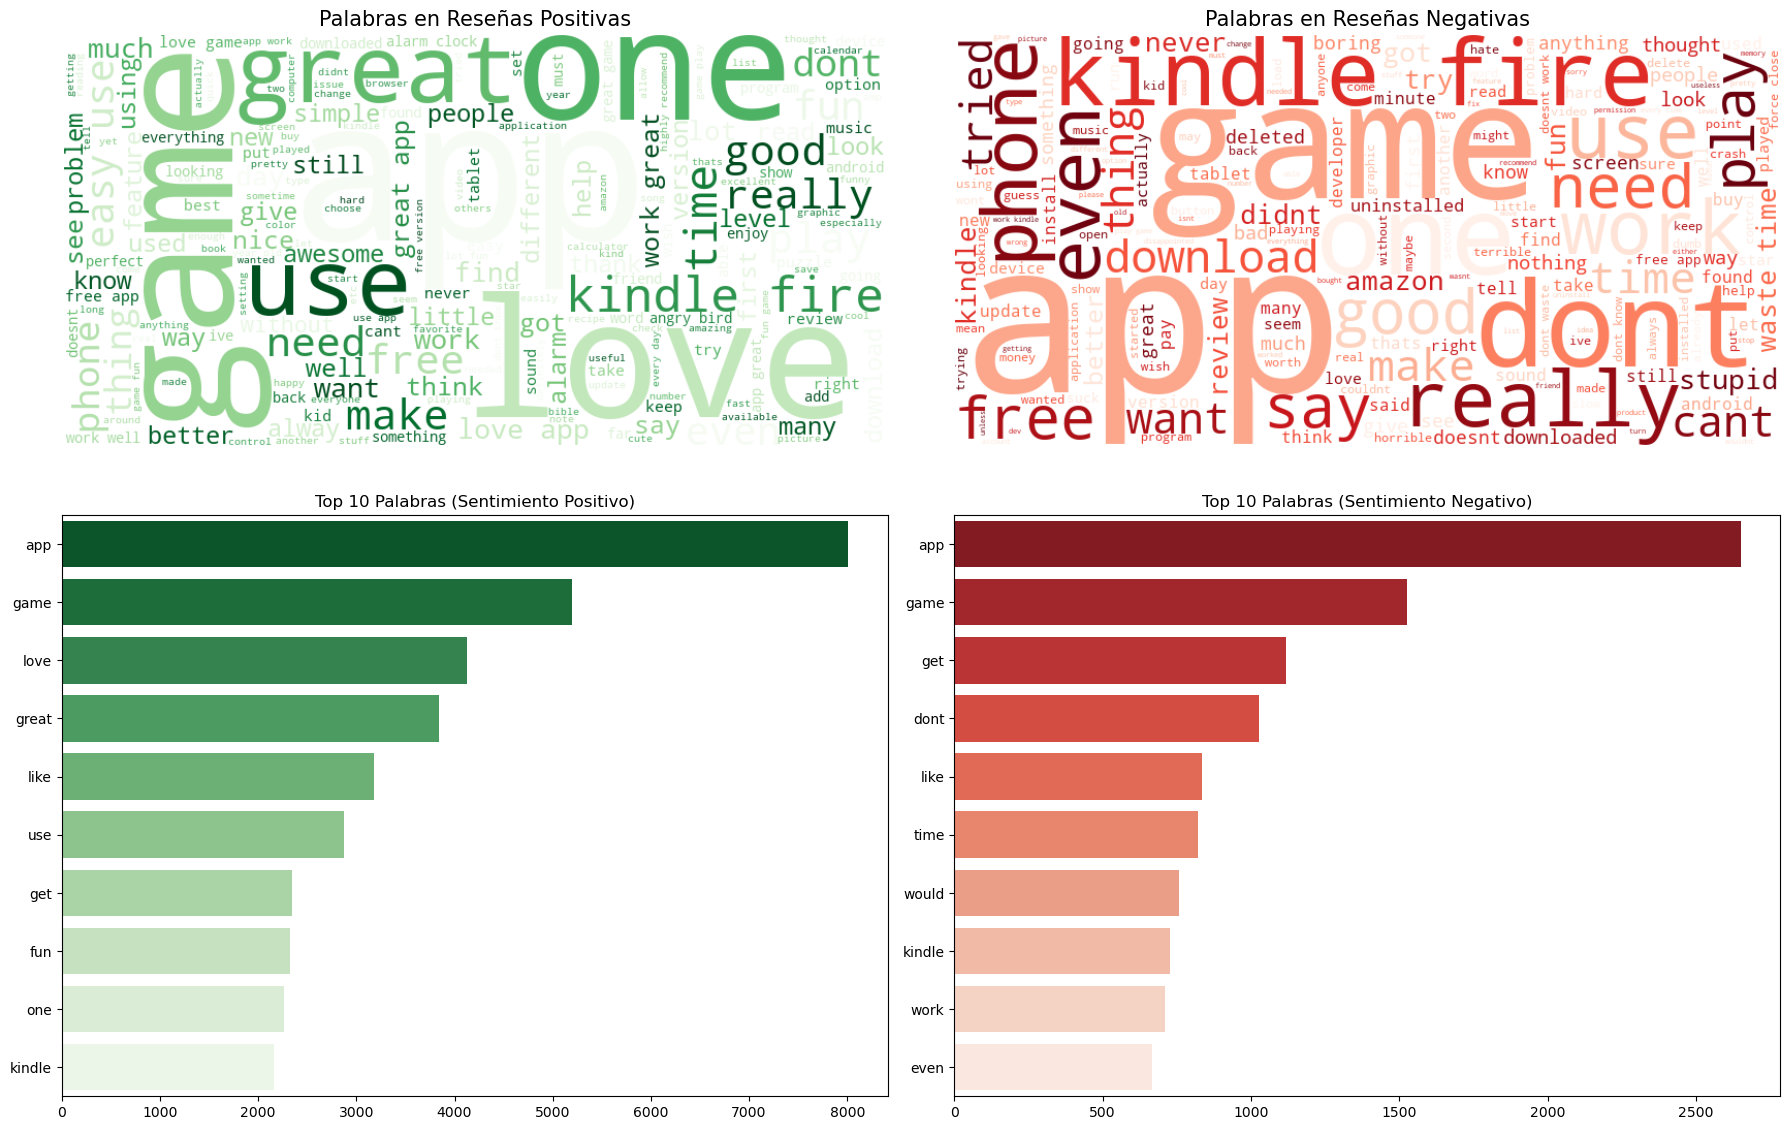


--- ANÁLISIS DE LOS RESULTADOS ---
Palabra más frecuente en positivos: 'app'
Palabra más frecuente en negativos: 'app'


In [4]:
from wordcloud import WordCloud
from collections import Counter

# Separamos los datos por sentimiento para compararlos
positivos = df[df['Positive'] == 1]['clean_text']
negativos = df[df['Positive'] == 0]['clean_text']

# Obtenemos las palabras más comunes
def obtener_frecuencias(dataset):
    todas_las_palabras = " ".join(dataset).split()
    return Counter(todas_las_palabras).most_common(10)

fig, ax = plt.subplots(2, 2, figsize=(18, 12))

# 1. Nube de Palabras - Positivas
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(" ".join(positivos))
ax[0, 0].imshow(wordcloud_pos, interpolation='bilinear')
ax[0, 0].set_title('Palabras en Reseñas Positivas', fontsize=15)
ax[0, 0].axis('off')

# 2. Nube de Palabras - Negativas
wordcloud_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(" ".join(negativos))
ax[0, 1].imshow(wordcloud_neg, interpolation='bilinear')
ax[0, 1].set_title('Palabras en Reseñas Negativas', fontsize=15)
ax[0, 1].axis('off')

# 3. Gráfico de Barras - Top 10 Positivas
top_pos = obtener_frecuencias(positivos)
words_p, counts_p = zip(*top_pos)
sns.barplot(x=list(counts_p), y=list(words_p), ax=ax[1, 0], palette='Greens_r')
ax[1, 0].set_title('Top 10 Palabras (Sentimiento Positivo)')

# 4. Gráfico de Barras - Top 10 Negativas
top_neg = obtener_frecuencias(negativos)
words_n, counts_n = zip(*top_neg)
sns.barplot(x=list(counts_n), y=list(words_n), ax=ax[1, 1], palette='Reds_r')
ax[1, 1].set_title('Top 10 Palabras (Sentimiento Negativo)')

plt.tight_layout()
plt.show()

print("\n--- ANÁLISIS DE LOS RESULTADOS ---")
print(f"Palabra más frecuente en positivos: '{top_pos[0][0]}'")
print(f"Palabra más frecuente en negativos: '{top_neg[0][0]}'")

## **4. Aplicación de Algoritmos de ML - Aprendizaje Supervisado**


>>> MÉTRICAS PARA NAIVE BAYES <<<
Precisión General (Accuracy): 0.8523
              precision    recall  f1-score   support

    Negativo       0.90      0.42      0.57      1411
    Positivo       0.85      0.99      0.91      4589

    accuracy                           0.85      6000
   macro avg       0.87      0.70      0.74      6000
weighted avg       0.86      0.85      0.83      6000


>>> MÉTRICAS PARA REGRESIÓN LOGÍSTICA <<<
Precisión General (Accuracy): 0.8892
              precision    recall  f1-score   support

    Negativo       0.86      0.64      0.73      1411
    Positivo       0.90      0.97      0.93      4589

    accuracy                           0.89      6000
   macro avg       0.88      0.80      0.83      6000
weighted avg       0.89      0.89      0.88      6000



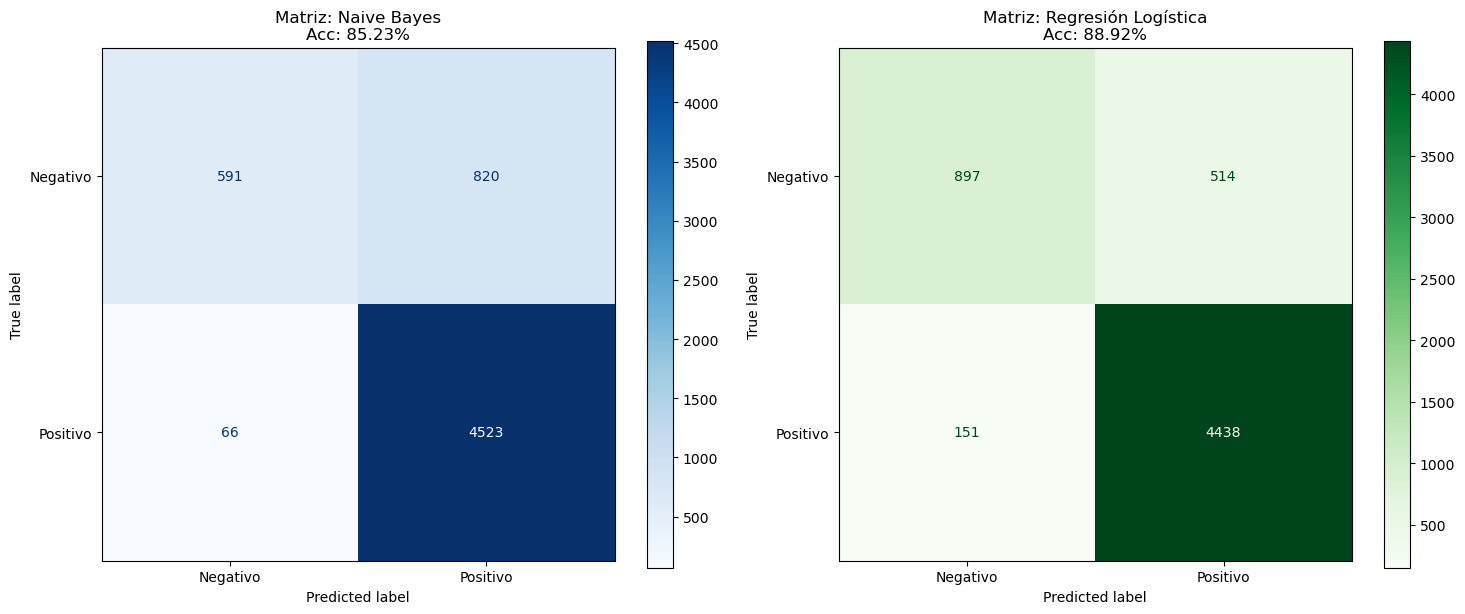


Observación: Tras la comparativa, el modelo con mejor desempeño es: **Regresión Logística**


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Convertimos el texto limpio en una matriz de números (TF-IDF)
vectorizador = TfidfVectorizer(max_features=5000)
X = vectorizador.fit_transform(df['clean_text'])
y = df['Positive']

# 70% Entrenamiento / 30% Prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Modelo 1: Naive Bayes
modelo_nb = MultinomialNB()
modelo_nb.fit(X_train, y_train)
pred_nb = modelo_nb.predict(X_test)

# Modelo 2: Regresión Logística
modelo_lr = LogisticRegression(max_iter=1000)
modelo_lr.fit(X_train, y_train)
pred_lr = modelo_lr.predict(X_test)

# EVALUACIÓN DE AMBOS MODELOS

def mostrar_metricas(nombre, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    print(f"\n>>> MÉTRICAS PARA {nombre.upper()} <<<")
    print(f"Precisión General (Accuracy): {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=['Negativo', 'Positivo']))
    return acc

acc_nb = mostrar_metricas("Naive Bayes", y_test, pred_nb)
acc_lr = mostrar_metricas("Regresión Logística", y_test, pred_lr)

# COMPARATIVA VISUAL (Matrices de Confusión)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Matriz para Naive Bayes
ConfusionMatrixDisplay.from_predictions(y_test, pred_nb,
                                        display_labels=['Negativo', 'Positivo'],
                                        cmap='Blues', ax=ax[0])
ax[0].set_title(f'Matriz: Naive Bayes\nAcc: {acc_nb:.2%}')

# Matriz para Regresión Logística
ConfusionMatrixDisplay.from_predictions(y_test, pred_lr,
                                        display_labels=['Negativo', 'Positivo'],
                                        cmap='Greens', ax=ax[1])
ax[1].set_title(f'Matriz: Regresión Logística\nAcc: {acc_lr:.2%}')

plt.tight_layout()
plt.show()

# --- Observaciones ---


## **5. Modelado de Tópicos (LDA) - Aprendizaje No Supervisado**

In [6]:
!pip install gensim
import gensim
from gensim import corpora

# 1. Preparamos los datos para LDA
textos_divididos = [texto.split() for texto in df['clean_text']]

# 2. Creamos un diccionario
diccionario = corpora.Dictionary(textos_divididos)

# Filtramos palabras:
# - Que aparezcan en menos de 5 reseñas (muy raras)
# - Que aparezcan en más del 50% de las reseñas (muy comunes/sin valor)
diccionario.filter_extremes(no_below=5, no_above=0.5)

# 3. Creamos el Corpus: Una "bolsa de palabras" (Bag of Words) para cada reseña
corpus = [diccionario.doc2bow(text) for text in textos_divididos]

# 4. Entrenamos el modelo LDA para encontrar 5 temas ocultos
print("Buscando temas ocultos en las reseñas, esto puede tomar un minuto.")
lda_model = gensim.models.LdaModel(corpus=corpus, id2word=diccionario,
                                   num_topics=5, random_state=42, passes=10)

# 5. Mostramos los temas encontrados con sus 10 palabras más importantes
print("\n--- LOS 5 TEMAS PRINCIPALES DETECTADOS ---")
print("La IA encontró que las reseñas hablan principalmente de estos 5 grupos de palabras:\n")

for idx, topic in lda_model.print_topics(-1):
    # Limpiamos un poco el formato para que sea legible
    palabras_clave = topic.split('"')[1::2]
    print(f"Tema #{idx+1}: {', '.join(palabras_clave)}")


Buscando temas ocultos en las reseñas, esto puede tomar un minuto.

--- LOS 5 TEMAS PRINCIPALES DETECTADOS ---
La IA encontró que las reseñas hablan principalmente de estos 5 grupos de palabras:

Tema #1: app, use, kindle, fire, great, easy, love, work, like, one
Tema #2: app, free, work, version, got, phone, one, amazon, download, tried
Tema #3: app, alarm, love, great, like, use, one, day, set, time
Tema #4: dont, app, get, even, time, like, know, say, people, would
Tema #5: game, fun, love, play, like, great, get, really, time, playing


c:\Users\carlo\anaconda3\lib\site-packages\seaborn\_core.py:1485: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
c:\Users\carlo\anaconda3\lib\site-packages\seaborn\_core.py:1485: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
c:\Users\carlo\anaconda3\lib\site-packages\seaborn\_core.py:1485: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
c:\Users\carlo\anaconda3\lib\site-packages\seaborn\_core.py:1485: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
c:\Users\carlo\anaconda3\lib

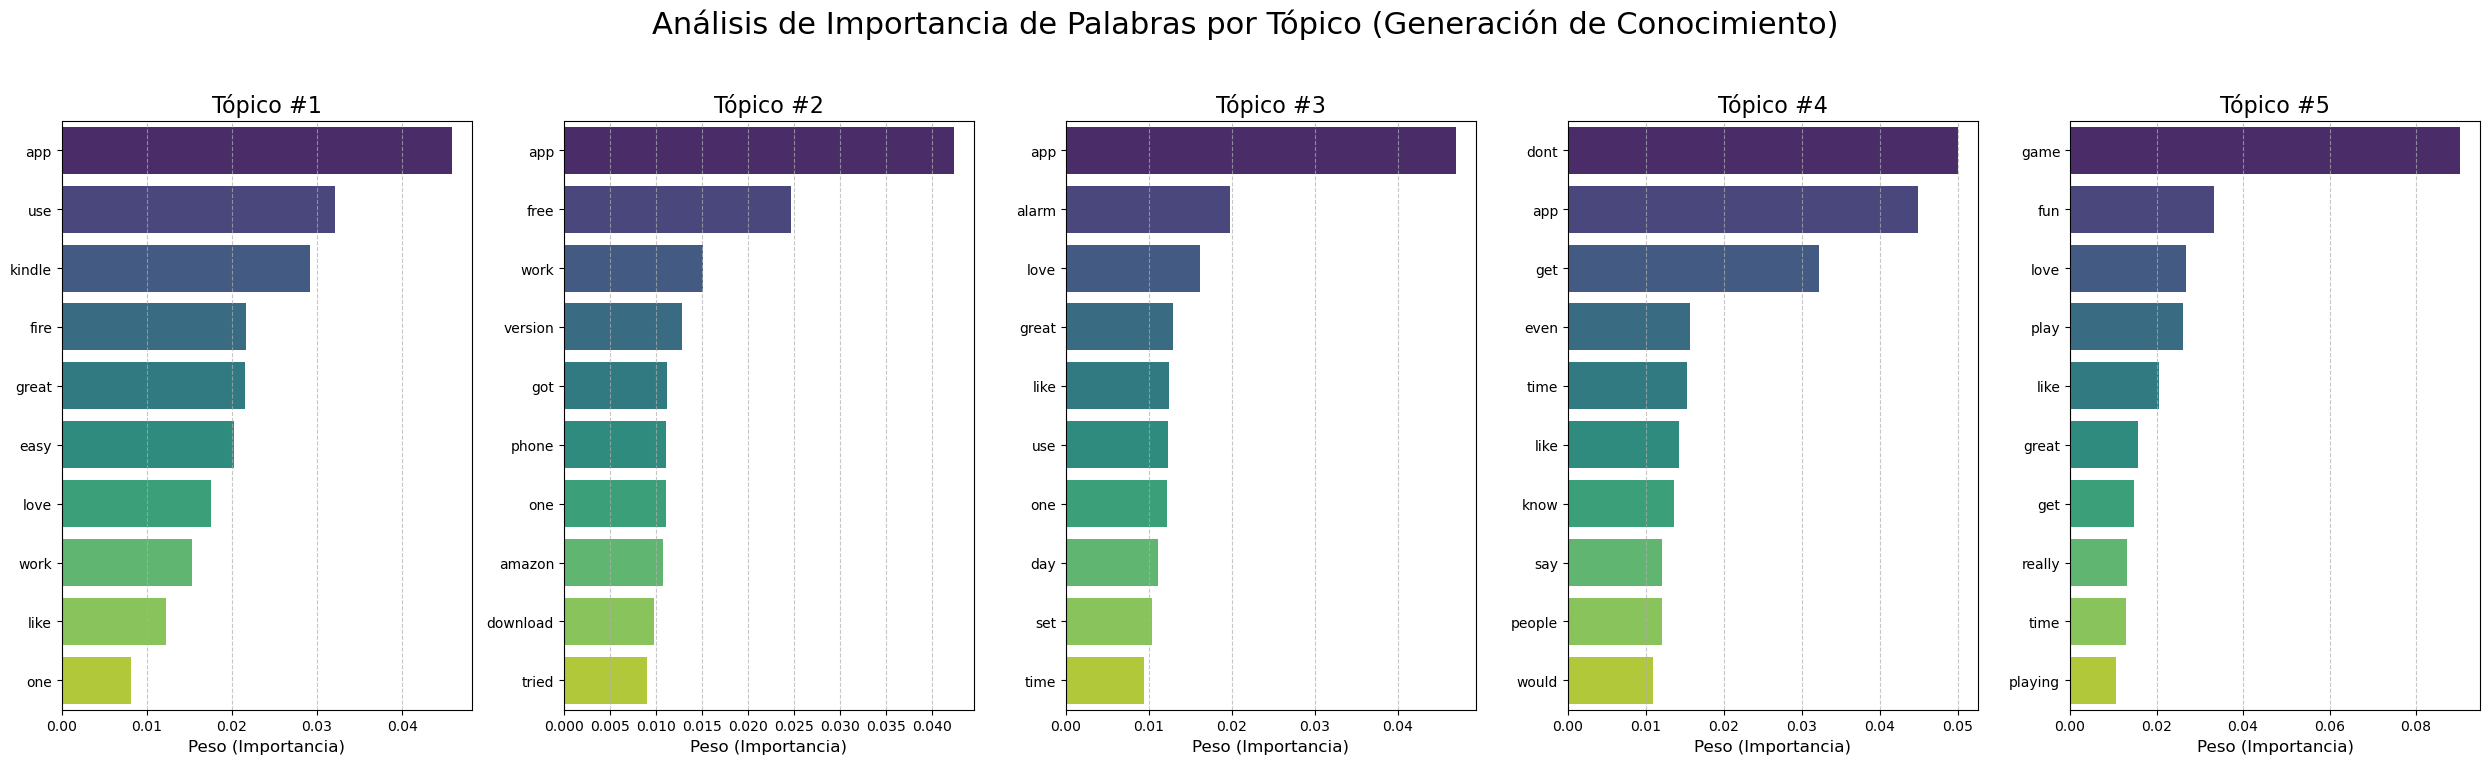

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extraemos los datos de los tópicos del modelo LDA
topics = lda_model.show_topics(formatted=False, num_words=10)

fig, axes = plt.subplots(1, 5, figsize=(25, 8), sharey=False)
fig.suptitle('Análisis de Importancia de Palabras por Tópico (Generación de Conocimiento)', fontsize=22)

# Iteramos sobre cada tópico para crear su gráfica
for i, (topic_num, words) in enumerate(topics):
    # Separamos las palabras y sus pesos (probabilidades)
    palabras = [w[0] for w in words]
    pesos = [w[1] for w in words]

    # Creamos la gráfica de barras horizontal
    sns.barplot(x=pesos, y=palabras, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Tópico #{i+1}', fontsize=16)
    axes[i].set_xlabel('Peso (Importancia)', fontsize=12)
    axes[i].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


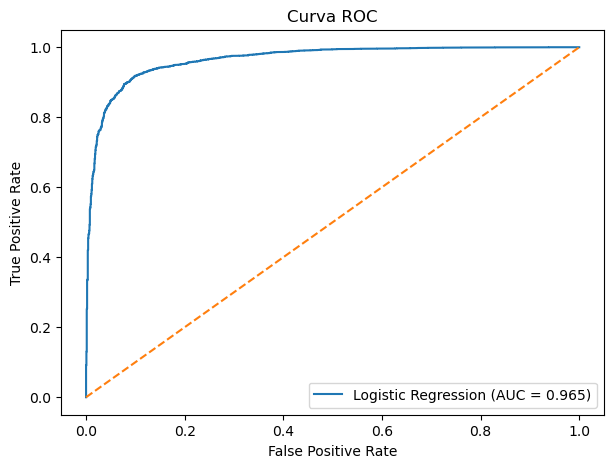

In [8]:
from sklearn.metrics import roc_auc_score, roc_curve

proba_lr = modelo_lr.predict_proba(X_test)[:, 1]
auc_lr = roc_auc_score(y_test, proba_lr)

fpr, tpr, _ = roc_curve(y_test, proba_lr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.show()


In [9]:
feature_names = vectorizador.get_feature_names_out()
coeficientes = modelo_lr.coef_[0]

top_positivas_idx = coeficientes.argsort()[-15:]
top_negativas_idx = coeficientes.argsort()[:15]

top_positivas = pd.DataFrame({
    'palabra': feature_names[top_positivas_idx],
    'peso': coeficientes[top_positivas_idx]
}).sort_values('peso', ascending=False)

top_negativas = pd.DataFrame({
    'palabra': feature_names[top_negativas_idx],
    'peso': coeficientes[top_negativas_idx]
}).sort_values('peso', ascending=True)

print("Palabras más asociadas a reseñas positivas:")
display(top_positivas)

print("Palabras más asociadas a reseñas negativas:")
display(top_negativas)

Palabras más asociadas a reseñas positivas:


,palabra,peso
14,love,8.515289
13,great,8.180142
12,easy,5.521839
11,awesome,4.554585
10,best,4.414140
9,fun,4.168780
8,nice,3.225192
7,amazing,3.139577
6,perfect,3.129670
5,well,2.884359


Palabras más asociadas a reseñas negativas:


,palabra,peso
0,waste,-5.214134
1,deleted,-4.888026
2,uninstalled,-4.447272
3,boring,-4.211927
4,useless,-3.827055
5,suck,-3.671735
6,didnt,-3.563587
7,worst,-3.310436
8,stupid,-3.289344
9,fix,-3.126819


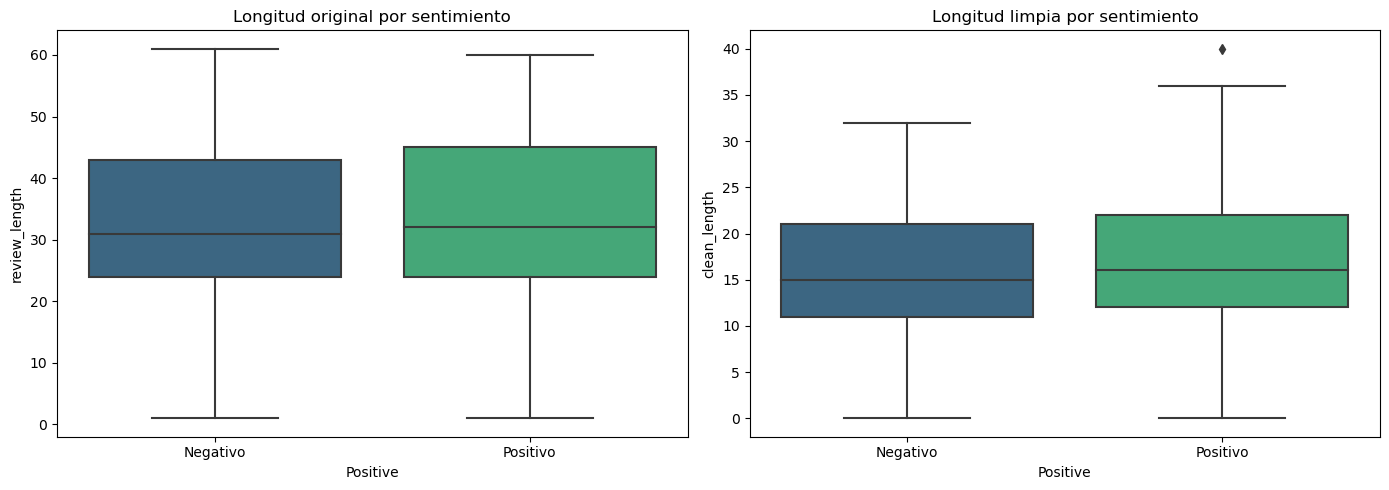

In [10]:
df['review_length'] = df['reviewText'].apply(lambda x: len(str(x).split()))
df['clean_length'] = df['clean_text'].apply(lambda x: len(str(x).split()))

fig, ax = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(data=df, x='Positive', y='review_length', ax=ax[0], palette='viridis')
ax[0].set_title('Longitud original por sentimiento')
ax[0].set_xticklabels(['Negativo', 'Positivo'])

sns.boxplot(data=df, x='Positive', y='clean_length', ax=ax[1], palette='viridis')
ax[1].set_title('Longitud limpia por sentimiento')
ax[1].set_xticklabels(['Negativo', 'Positivo'])

plt.tight_layout()
plt.show()

In [11]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

df['vader_score'] = df['reviewText'].apply(lambda x: sia.polarity_scores(str(x))['compound'])
df['vader_pred'] = df['vader_score'].apply(lambda x: 1 if x >= 0 else 0)

from sklearn.metrics import accuracy_score, classification_report

print("Resultados VADER")
print("Accuracy:", accuracy_score(df['Positive'], df['vader_pred']))
print(classification_report(df['Positive'], df['vader_pred'], target_names=['Negativo', 'Positivo']))

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\carlo\AppData\Roaming\nltk_data...


Resultados VADER
Accuracy: 0.82175
              precision    recall  f1-score   support

    Negativo       0.66      0.52      0.58      4767
    Positivo       0.86      0.92      0.89     15233

    accuracy                           0.82     20000
   macro avg       0.76      0.72      0.73     20000
weighted avg       0.81      0.82      0.81     20000



In [12]:
# Obtener tópico dominante por documento
topico_dominante = []

for doc in corpus:
    topicos_doc = lda_model.get_document_topics(doc)
    topico_principal = max(topicos_doc, key=lambda x: x[1])[0]
    topico_dominante.append(topico_principal)

df['topico_dominante'] = topico_dominante

tabla_topicos = pd.crosstab(df['topico_dominante'], df['Positive'], normalize='index')
tabla_topicos.columns = ['Negativo', 'Positivo']

tabla_topicos

,Negativo,Positivo
topico_dominante,,
0,0.098561,0.901439
1,0.443491,0.556509
2,0.141852,0.858148
3,0.622072,0.377928
4,0.134114,0.865886


In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score

resumen_modelos = pd.DataFrame({
    'Modelo': ['Naive Bayes', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_test, pred_nb),
        accuracy_score(y_test, pred_lr)
    ],
    'Precision': [
        precision_score(y_test, pred_nb),
        precision_score(y_test, pred_lr)
    ],
    'Recall': [
        recall_score(y_test, pred_nb),
        recall_score(y_test, pred_lr)
    ],
    'F1 Score': [
        f1_score(y_test, pred_nb),
        f1_score(y_test, pred_lr)
    ]
})

resumen_modelos

,Modelo,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.705167,0.762119,0.891028,0.821547
1,Logistic Regression,0.668000,0.760299,0.823851,0.790800


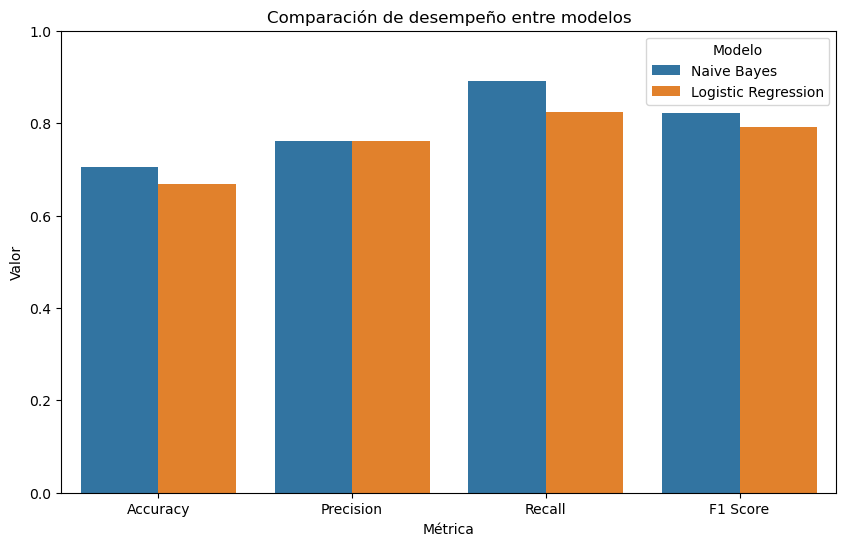

In [14]:
df_plot = resumen_modelos.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

plt.figure(figsize=(10,6))
sns.barplot(data=df_plot, x='Métrica', y='Valor', hue='Modelo')
plt.ylim(0,1)
plt.title('Comparación de desempeño entre modelos')
plt.show()